In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workalendar.asia import SouthKorea 

# statsmodel 확인
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from torch.utils.data import DataLoader, TensorDataset

# 오류 무시하는 방법
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/mnt/nvme/zongseung/SCI/기후데이터/demand_celcius.csv")
df = df.set_index("일시")
df = df.drop("Unnamed: 0", axis=1)
df.index = pd.to_datetime(df.index)

In [3]:
import datetime as dt
cal = SouthKorea()

def holiday_weekday(data):
    holiday_data = []

    for date in data.index:

        if date.weekday() in [5, 6] or cal.is_holiday(date) is True:  # 주말 (토요일=5, 일요일=6) / 공휴일까지 포함시켜서 확인한다.
            holiday_data.append(2) # 2번은 쉬는날
        else:  # 그 외 날짜 
            holiday_data.append(1) # 안쉬는날

    data["holiday_data"] = holiday_data    
    
    return data

def get_season_by_month(month):
    asd = []
    
    for i in month: 
        if 3 <= i <= 5: 
            asd.append(1) # 봄
        elif 6 <= i <= 8:
            asd.append(2) # 여름
        elif 9 <= i <= 11:
            asd.append(3)
        else:
            asd.append(4)
    return asd

In [4]:
df["month"] = df.index.month

df_holiday = holiday_weekday(df)
df_holiday["season"] = get_season_by_month(df_holiday["month"])

In [5]:
# 더미 변수 생성 알고리즘
def select_date(data):

        dummies = pd.get_dummies(data["holiday_data"]).astype("int")
        season_dummies = pd.get_dummies(data["season"]).astype("int")
        
        data = pd.concat([data, dummies], axis = 1)
        data.drop(["holiday_data", "season"], axis=1, inplace=True)

        data.rename(columns = {1:"weekday",
        2:"weekend"}, inplace=True)

        data = pd.concat([data, season_dummies], axis = 1)

        data.rename(columns = {1:"spring",
        2:"summer",
        3:"autoum",
        4:"winter"}, inplace=True)
        
        return data

In [6]:
import datetime as dt
df.reset_index(inplace=True)
# 연,월,일 생성
df["ymd"] = df["일시"].dt.strftime('%Y-%m-%d')

# 더미 변수 생성
df = select_date(df)

Text(0.5, 1.0, '2019 jan demand data')

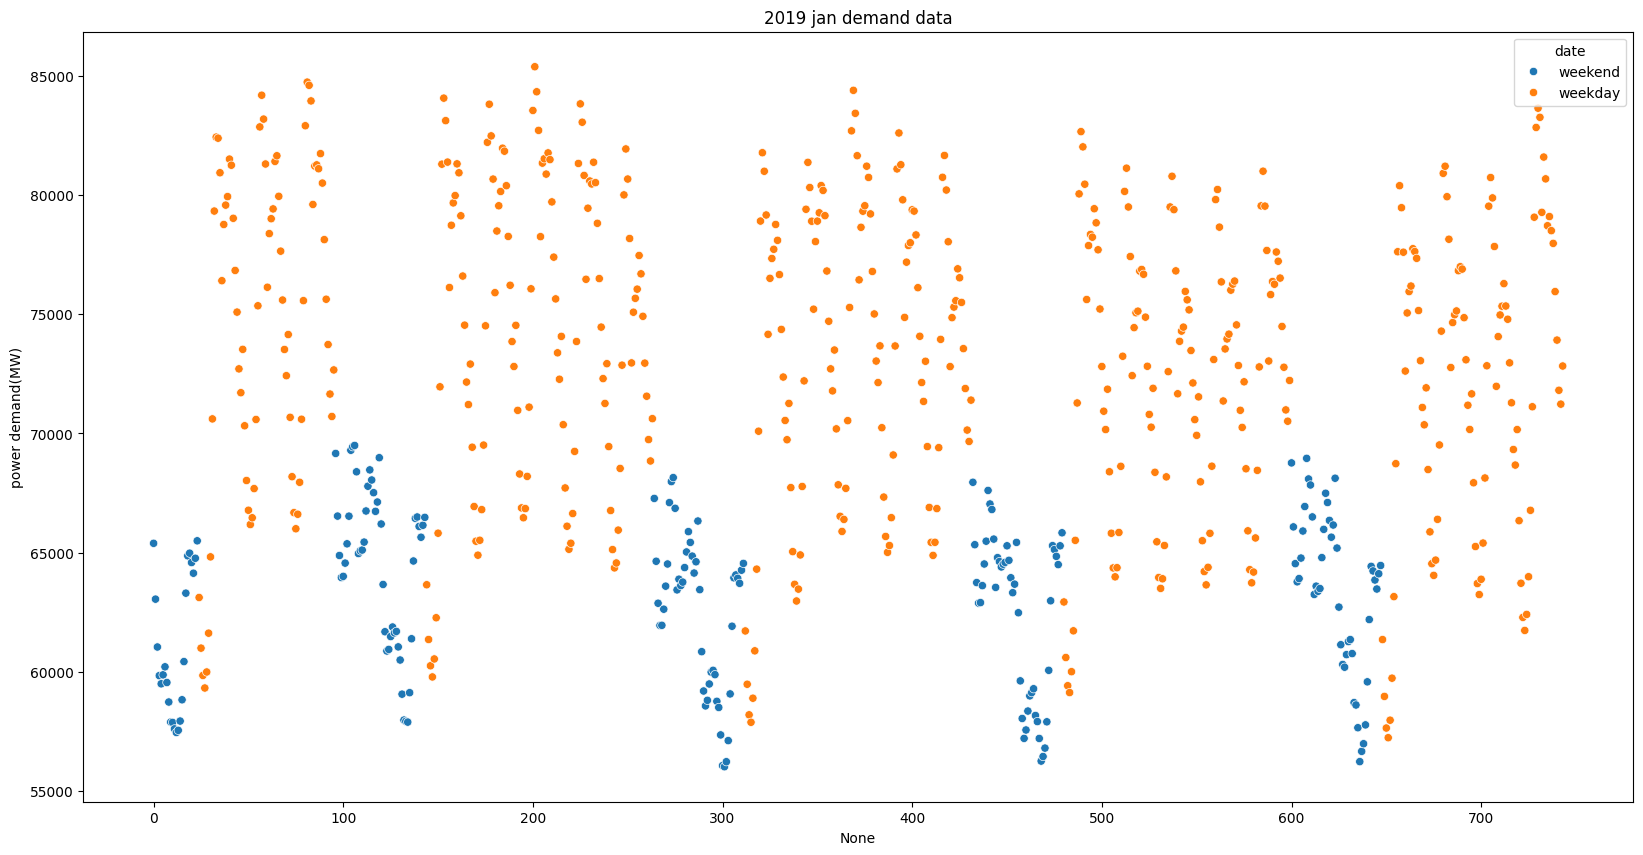

In [7]:
import seaborn as sns
df["date"] = df[["weekday", "weekend"]].idxmax(axis=1)

plt.figure(figsize=(20,10))
sns.scatterplot(x= df[:31*24].index,y=df["power demand(MW)"][:31*24], hue=df["date"][:31*24])
plt.title("2019 jan demand data")

In [8]:
from lunarcalendar import Converter, Solar, Lunar

def get_solar_date(year, lunar_month, lunar_day):
    """음력 날짜를 양력으로 변환"""
    lunar_date = Lunar(year, lunar_month, lunar_day)
    solar_date = Converter.Lunar2Solar(lunar_date)
    return pd.Timestamp(solar_date.year, solar_date.month, solar_date.day)  # pandas Timestamp 변환

# 2019~2024년의 설날과 추석 날짜 계산 및 연휴 포함
# 2019~2024년의 설날과 추석 날짜 계산 및 연휴 포함
holiday_dict = {}
for year in range(2019, 2025):
    seollal = get_solar_date(year, 1, 1)  # 설날 본날
    chuseok = get_solar_date(year, 8, 15)  # 추석 본날

    # 연휴 포함 (전날, 당일, 다음날)
    if year==2019:
        
        holiday_dict[seollal - pd.Timedelta(days=1)] = "seol"
        holiday_dict[seollal] = "seol"
        holiday_dict[seollal + pd.Timedelta(days=1)] = "seol"

    
    elif year == 2023:
        holiday_dict[chuseok - pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=2)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=3)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=4)] = "Chuseok"
    
    # 일반적으로 표기하는 경우
    else:
        # 설날
        holiday_dict[seollal - pd.Timedelta(days=1)] = "seol"
        holiday_dict[seollal] = "seol"
        holiday_dict[seollal + pd.Timedelta(days=1)] = "seol"
        # 추석
        holiday_dict[chuseok - pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=1)] = "Chuseok"

        
# `holiday_type` 컬럼 추가
df["ymd"] = pd.to_datetime(df["ymd"])
df["holiday_type"] = df["ymd"].map(holiday_dict)

## 그럼 최대 전력수요에 빗대에서 확인하자

In [16]:
# 24시간 중 최대부하 데이터 추출하기
def filtering_max_per_day(df):
    idx = df.groupby("ymd")["power demand(MW)"].idxmax()  # 최대값 인덱스
    max_per_day = df.loc[idx, ["ymd", "hm", "ta", "weekday", "weekend", "power demand(MW)", "spring", "summer","autoum", "winter"]]  # 최대값과 시간 -> "hm",	"ta", "power demand(MW)", "weekday", "weekend"
    
    max_per_day = max_per_day.rename(columns={"power demand(MW)": "max_power"})
    
    return max_per_day.reset_index(drop=True)

max_date = filtering_max_per_day(df)
max_date.set_index("ymd", inplace=True)

In [17]:
def generate_max_power_and_degree_days(df, base_temp=18.0):
    # 최대 전력수요 시점 정보 추출
    idx = df.groupby("ymd")["power demand(MW)"].idxmax()
    max_per_day = df.loc[idx, ["ymd", "hm", "ta", "weekday", "weekend",
                                "power demand(MW)", "spring", "summer", "autoum", "winter"]]
    max_per_day = max_per_day.rename(columns={"power demand(MW)": "max_power"})
    max_per_day.set_index("ymd", inplace=True)

    # 하루 최고/최저 기온 계산 → CDD, HDD 계산
    t_max = df.groupby("ymd")["ta"].max().rename("t_max")
    t_min = df.groupby("ymd")["ta"].min().rename("t_min")
    t_mean = ((t_max + t_min) / 2).rename("t_mean")
    cdd = (t_mean - base_temp).clip(lower=0).rename("CDD")
    hdd = (base_temp - t_mean).clip(lower=0).rename("HDD")

    degree_df = pd.concat([t_max, t_min, t_mean, cdd, hdd], axis=1)

    # 병합
    result = max_per_day.join(degree_df)

    return result.reset_index()



In [18]:
result_df = generate_max_power_and_degree_days(df)
print(result_df.head())

result_df.drop(["t_mean", "t_max", "t_min"] , axis=1, inplace = True)

         ymd         hm        ta  weekday  weekend  max_power  spring  \
0 2019-01-01  59.885979 -3.280564        0        1    65493.0       0   
1 2019-01-02  65.948589 -5.109383        1        0    82437.0       0   
2 2019-01-03  62.400529 -5.431358        1        0    84196.0       0   
3 2019-01-04  63.005115 -4.773677        1        0    84746.0       0   
4 2019-01-05  53.782407 -0.446138        0        1    69496.0       0   

   summer  autoum  winter     t_max     t_min    t_mean  CDD        HDD  
0       0       0       1  0.098810 -4.981931 -2.441561  0.0  20.441561  
1       0       0       1  1.213139 -6.374436 -2.580648  0.0  20.580648  
2       0       0       1  3.366217 -7.198404 -1.916093  0.0  19.916093  
3       0       0       1  3.725688 -6.715688 -1.495000  0.0  19.495000  
4       0       0       1  2.701182 -4.399030 -0.848924  0.0  18.848924  


In [19]:
result_df

,ymd,hm,ta,weekday,weekend,max_power,spring,summer,autoum,winter,CDD,HDD
0,2019-01-01,59.885979,-3.280564,0,1,65493.0,0,0,0,1,0.0,20.441561
1,2019-01-02,65.948589,-5.109383,1,0,82437.0,0,0,0,1,0.0,20.580648
2,2019-01-03,62.400529,-5.431358,1,0,84196.0,0,0,0,1,0.0,19.916093
3,2019-01-04,63.005115,-4.773677,1,0,84746.0,0,0,0,1,0.0,19.495000
4,2019-01-05,53.782407,-0.446138,0,1,69496.0,0,0,0,1,0.0,18.848924
...,...,...,...,...,...,...,...,...,...,...,...,...
2126,2024-10-27,85.027337,16.226358,0,1,59386.0,0,0,1,0,0.0,2.446561
2127,2024-10-28,74.152557,16.683915,1,0,69316.0,0,0,1,0,0.0,2.774198
2128,2024-10-29,73.509259,15.950529,1,0,69236.0,0,0,1,0,0.0,2.130922
2129,2024-10-30,69.923280,16.556958,1,0,68664.0,0,0,1,0,0.0,2.434422


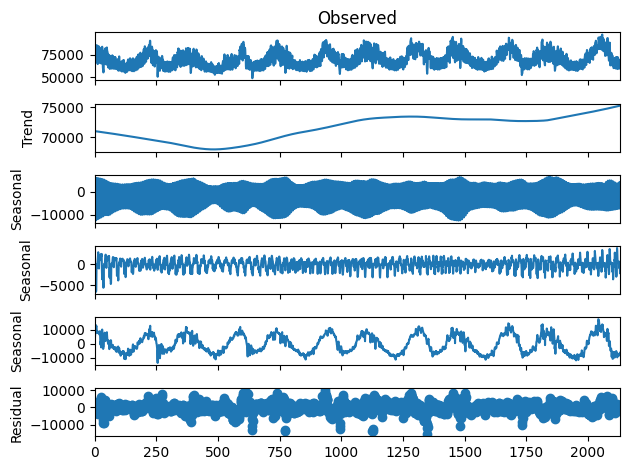

In [20]:
from statsmodels.tsa.seasonal import MSTL
res = MSTL(result_df["max_power"].values, periods=[7, 30, 365]).fit()

res.plot();

In [21]:
result_df

,ymd,hm,ta,weekday,weekend,max_power,spring,summer,autoum,winter,CDD,HDD
0,2019-01-01,59.885979,-3.280564,0,1,65493.0,0,0,0,1,0.0,20.441561
1,2019-01-02,65.948589,-5.109383,1,0,82437.0,0,0,0,1,0.0,20.580648
2,2019-01-03,62.400529,-5.431358,1,0,84196.0,0,0,0,1,0.0,19.916093
3,2019-01-04,63.005115,-4.773677,1,0,84746.0,0,0,0,1,0.0,19.495000
4,2019-01-05,53.782407,-0.446138,0,1,69496.0,0,0,0,1,0.0,18.848924
...,...,...,...,...,...,...,...,...,...,...,...,...
2126,2024-10-27,85.027337,16.226358,0,1,59386.0,0,0,1,0,0.0,2.446561
2127,2024-10-28,74.152557,16.683915,1,0,69316.0,0,0,1,0,0.0,2.774198
2128,2024-10-29,73.509259,15.950529,1,0,69236.0,0,0,1,0,0.0,2.130922
2129,2024-10-30,69.923280,16.556958,1,0,68664.0,0,0,1,0,0.0,2.434422


In [22]:
len(result_df)

2131

In [23]:
result_df[["hm", "ta", "weekday", "weekend",	"spring", "summer", "autoum", "winter", "CDD", "HDD","multiple_season"]]

KeyError: "['multiple_season'] not in index"

In [24]:
observed = res.observed
trend = res.trend
seasonal = res.seasonal  # shape: (n_samples, n_seasons)

# 전체 계절 성분 합산
seasonal_sum = seasonal.sum(axis=1)

# Residual 계산
residual = observed - trend - seasonal_sum
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# train - (val) - test 로 분할 실시한다. 7:1.5:1.5
## AR의 모형을 기반으로 분할 -> 예는 
# 분할 인덱스
total_len = len(result_df)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)
##################################3#################3#################3#################3#################3#################3
trend_train = trend[:val_end] #이를 기반으로 AR 모형 생성
trend_test = trend[val_end:] #이를 기반으로 AR 모형 생성
#### multiple-seasonality + 외부변수 기반 예측 사용 ####
result_df["multiple_season"] = seasonal_sum
result_df1 = result_df[["hm", "ta", "weekday", "weekend",	"spring", "summer", "autoum", "winter", "CDD", "HDD","multiple_season"]]

train_df = result_df1.iloc[:train_end].copy()
val_df = result_df1.iloc[train_end:val_end].copy()
test_df = result_df1.iloc[val_end:].copy()

#----- 잔차 모델링 ----------
## residual 사용 -> 이때 자기상관성이 있는지 모델링
train_residual = residual[:train_end].copy()
val_residual = residual[train_end:val_end].copy()
test_residual = residual[val_end:].copy()

In [15]:
from statsmodels.tsa.ar_model import ar_select_order

# 예: trend_train 기반으로 AR 차수 선택
sel = ar_select_order(trend_train, maxlag=15, ic='aic', old_names=False)
print("추천 lag:", sel.ar_lags)


NameError: name 'trend_train' is not defined

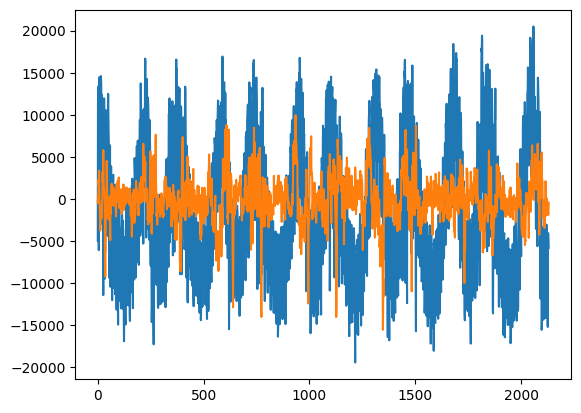

In [25]:
plt.plot(seasonal_sum);
plt.plot(residual);

In [78]:
from pmdarima import auto_arima

model = auto_arima(trend_train,
                   start_p=0, start_q=0,
                   max_p=5, max_q=5,
                   seasonal=False,
                   d=1,            # 자동 추정
                   stepwise=True,
                   trace=True)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11694.110, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11736.179, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-6770.648, Time=0.70 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-8357.538, Time=0.90 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-8345.898, Time=2.21 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-6768.100, Time=3.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-7138.959, Time=0.98 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-8356.629, Time=2.72 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-8355.335, Time=0.29 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0] intercept
Total fit time: 12.711 seconds


In [26]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

def rolling_arima_forecast(train_series, test_series, p=2, d=1, q=1, window_size=7):
    """
    train_series: 학습 시계열 (numpy or Series)
    test_series: 테스트 시계열 (예측 대상)
    p, d, q: ARIMA 차수
    window_size: None이면 누적 방식, 값 주면 슬라이딩 윈도우
    """
    history = list(train_series)
    preds = []

    for t in range(len(test_series)):
        # 학습 구간 설정
        if window_size is not None:
            train_window = history[-window_size:]
        else:
            train_window = history

        model = ARIMA(train_window, order=(p, d, q))
        model_fit = model.fit()

        # 1-step ahead forecast
        pred = model_fit.forecast()[0]
        preds.append(pred)

        # 실제값 추가 (실제 예측 환경 가정)
        history.append(test_series[t])

    return np.array(preds)



In [80]:
# train = trend[:val_end], test = trend[val_end:]
arima_preds = rolling_arima_forecast(trend[:val_end], trend[val_end:], p=2, d=1, q=1)


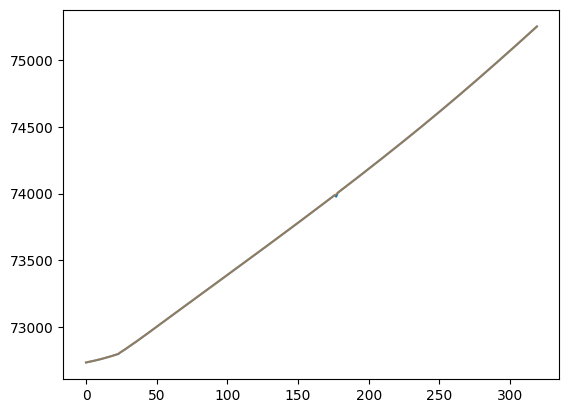

In [81]:
plt.plot(arima_preds)
plt.plot(trend_test, alpha=0.5)

In [94]:
# 슬라이딩 윈도우
def sliding_window(datax, datay, window_size):
    x = []
    y = []
    
    for i in range(len(datax) - window_size + 1):
        xx = datax[i:window_size + i]  # 윈도우 크기 만큼 입력 생성
        yy = datay[window_size + i - 1]  # 윈도우의 마지막 값을 출력으로 설정
        x.append(xx)
        y.append(yy)
    
    return np.array(x), np.array(y)

# 1차 표준화
from sklearn.preprocessing import MinMaxScaler
mnx1 = MinMaxScaler()
mny1 = MinMaxScaler()

scaled_train_x1 = mnx1.fit_transform(train_df.drop("multiple_season", axis=1))
scaled_val_x1 = mnx1.transform(val_df.drop("multiple_season", axis=1))
scaled_test_x1 = mnx1.transform(test_df.drop("multiple_season", axis=1))

# 올바르게
scaled_train_y1 = mny1.fit_transform(train_df[["multiple_season"]]).flatten()
scaled_val_y1   = mny1.transform(  val_df[["multiple_season"]]).flatten()
scaled_test_y1  = mny1.transform( test_df[["multiple_season"]]).flatten()

# 3) 스케일된 배열에 슬라이딩 윈도우 적용
window_size = 7
Xtr, ytr = sliding_window(scaled_train_x1, scaled_train_y1, window_size)
Xva, yva = sliding_window(scaled_val_x1,   scaled_val_y1,   window_size)
Xte, yte = sliding_window(scaled_test_x1,  scaled_test_y1,  window_size)


##############################################################################################################
mnx2 = MinMaxScaler()
mny2 = MinMaxScaler()

# 
# 슬라이딩 윈도우
def sliding_window_residual(datax, window_size):
    x = []
    y = []
    
    for i in range(len(datax) - window_size + 1):
        xx = datax[i:window_size + i]  # 윈도우 크기 만큼 입력 생성
        yy = datax[window_size + i - 1]  # 윈도우의 마지막 값을 출력으로 설정
        x.append(xx)
        y.append(yy)
    
    return np.array(x), np.array(y)

scaled_train_residual = mnx2.fit_transform(train_residual.reshape(-1,1))
scaled_val_residual = mnx2.transform(val_residual.reshape(-1,1))
scaled_test_residual = mnx2.transform(test_residual.reshape(-1,1))

Xtr1, ytr1 = sliding_window_residual(scaled_train_residual, window_size=7)
Xva1, yva1 = sliding_window_residual(scaled_val_residual,   window_size=7)
Xte1, yte1 = sliding_window_residual(scaled_test_residual,  window_size=7)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import itertools
import numpy as np
torch.backends.cudnn.benchmark = True 
torch.backends.cudnn.enabled = True
#############################################
# 1. LSTM + Bahdanau Attention 모델 정의
#############################################
class LSTM_Attention_Model(nn.Module):
    def __init__(self, lstm_layers, dense_layers, units, dense_units,
                 lstm_dropout_rate, dense_dropout_rate, attn_hidden_dim,
                 input_features):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=units,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout_rate
        )
        # Bahdanau Attention 파라미터
        self.attn_W = nn.Linear(units, attn_hidden_dim)
        self.attn_U = nn.Linear(units, attn_hidden_dim)
        self.attn_v = nn.Linear(attn_hidden_dim, 1)
        # Dense 레이어
        self.dense_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(units if i == 0 else dense_units, dense_units),
                nn.ReLU(),
                nn.Dropout(dense_dropout_rate)
            ) for i in range(dense_layers)
        ])
        # 출력 레이어
        out_dim = dense_units if dense_layers > 0 else units
        self.output_layer = nn.Linear(out_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x)               # (batch, seq_len, units)
        last_hidden = lstm_out[:, -1, :]         # (batch, units)
        # Bahdanau Attention 계산
        score = torch.tanh(self.attn_W(lstm_out) + self.attn_U(last_hidden).unsqueeze(1))  # (B, T, A)
        weights = torch.softmax(self.attn_v(score), dim=1)  # (B, T, 1)
        context = (weights * lstm_out).sum(dim=1)           # (B, units)
        # Dense 및 출력
        x = context
        for layer in self.dense_layers:
            x = layer(x)
        return self.output_layer(x)  # (B, 1)

#############################################
# 2. DataLoader 생성 함수
#############################################
def create_dataloader(X, y, batch_size):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=0, pin_memory=True)

#############################################
# 3. Fitness 함수 (Grid Search용)
#############################################
def evaluate_params(params, X_train, y_train, X_val, y_val, device):
    """
    params: dict with keys:
      lstm_layers, dense_layers, units, dense_units,
      learning_rate, lstm_dropout_rate, dense_dropout_rate,
      batch_size, attn_hidden_dim
    """
    # Unpack
    lstm_layers = int(params['lstm_layers'])
    dense_layers = int(params['dense_layers'])
    units = int(params['units'])
    dense_units = int(params['dense_units'])
    lr = params['learning_rate']
    lstm_dropout = params['lstm_dropout_rate']
    dense_dropout = params['dense_dropout_rate']
    batch_size = int(params['batch_size'])
    attn_hidden_dim = int(params['attn_hidden_dim'])

    input_features = X_train.shape[2]
    model = LSTM_Attention_Model(
        lstm_layers, dense_layers, units, dense_units,
        lstm_dropout, dense_dropout, attn_hidden_dim,
        input_features
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    train_loader = create_dataloader(X_train, y_train, batch_size)
    val_loader = create_dataloader(X_val, y_val, batch_size)

    # Training for a few epochs for evaluation
    model.train()
    epochs = 100
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss += criterion(preds, yb).item()
    return val_loss / len(val_loader)

#############################################
# 4. Hyperparameter Grid 설정
#############################################
param_grid = {
    'lstm_layers': [1, 2, 3],
    'dense_layers': [1, 2, 3],
    'units': [32, 64, 128, 256],
    'dense_units': [32, 64, 128, 256],
    'learning_rate': [1e-4, 1e-3, 1e-2],
    'lstm_dropout_rate': [0.1, 0.3, 0.5],
    'dense_dropout_rate': [0.1, 0.3, 0.5],
    'batch_size': [16, 32, 64, 128],
    'attn_hidden_dim': [16, 32, 64]
}

grid = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#############################################
# 6. Grid Search 실행
#############################################
best_loss = float('inf')
best_params = None

for combo in grid:
    params = dict(zip(param_names, combo))
    loss = evaluate_params(params, Xtr, ytr, Xva, yva, device)
    if loss < best_loss:
        best_loss, best_params = loss, params
        print(f"New Best: Val Loss={best_loss:.4f}, Params={best_params}")

print("Grid Search Complete")
print("Best Params:", best_params)
print("Best Val Loss:", best_loss)

#############################################
# 7. 최종 모델 학습 및 Test 평가 (수정 버전)
#############################################

# 7-1) Train+Val 데이터 병합 (features끼리, targets끼리)
#    (기존 np.vstack([Xtr, ytr]) → 잘못된 결합이었습니다)
X_trainval = np.concatenate([Xtr, Xva], axis=0)  # feature windows 합치기
y_trainval = np.concatenate([ytr, yva], axis=0)  # target windows 합치기

# 7-2) 최종 모델 초기화
final_model = LSTM_Attention_Model(
    lstm_layers=int(best_params['lstm_layers']),
    dense_layers=int(best_params['dense_layers']),
    units=int(best_params['units']),
    dense_units=int(best_params['dense_units']),
    lstm_dropout_rate=best_params['lstm_dropout_rate'],
    dense_dropout_rate=best_params['dense_dropout_rate'],
    attn_hidden_dim=int(best_params['attn_hidden_dim']),
    input_features=Xtr.shape[2]  # Xtr: (n_samples, seq_len, n_features)
).to(device)

optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])
criterion = nn.MSELoss()

# 7-3) DataLoader 생성 (batch_size도 best_params에서)
trainval_loader = create_dataloader(X_trainval, y_trainval, best_params['batch_size'])
test_loader     = create_dataloader(Xte,   yte,        best_params['batch_size'])

# 7-4) Train
final_model.train()
for epoch in range(100):
    for xb, yb in trainval_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(xb).squeeze(), yb)
        loss.backward()
        optimizer.step()

# 7-5) Test 평가
final_model.eval()
test_loss = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = final_model(xb).squeeze()
        test_loss += criterion(preds, yb).item()
test_loss /= len(test_loader)

print("Final Test Loss:", test_loss)

New Best: Val Loss=0.0072, Params={'lstm_layers': 1, 'dense_layers': 1, 'units': 32, 'dense_units': 32, 'learning_rate': 0.0001, 'lstm_dropout_rate': 0.1, 'dense_dropout_rate': 0.1, 'batch_size': 16, 'attn_hidden_dim': 16}
New Best: Val Loss=0.0072, Params={'lstm_layers': 1, 'dense_layers': 1, 'units': 32, 'dense_units': 32, 'learning_rate': 0.0001, 'lstm_dropout_rate': 0.1, 'dense_dropout_rate': 0.1, 'batch_size': 16, 'attn_hidden_dim': 64}
New Best: Val Loss=0.0070, Params={'lstm_layers': 1, 'dense_layers': 1, 'units': 32, 'dense_units': 32, 'learning_rate': 0.0001, 'lstm_dropout_rate': 0.1, 'dense_dropout_rate': 0.3, 'batch_size': 16, 'attn_hidden_dim': 16}


In [ ]:
#############################################
# 0. 이미 만들어둔 sliding_window_residual 호출 후
#    Xtr1, ytr1, Xva1, yva1, Xte1, yte1 준비된 상태라고 가정
#############################################

# 6. Grid Search 실행 (Residual 전용)
best_loss_res = float('inf')
best_params_res = None

for combo in grid:
    params = dict(zip(param_names, combo))
    # 여기만 Xtr1,ytr1, Xva1,yva1 로 바꿔줍니다
    loss = evaluate_params(params,
                           X_train = Xtr1,
                           y_train = ytr1,
                           X_val   = Xva1,
                           y_val   = yva1,
                           device  = device)
    if loss < best_loss_res:
        best_loss_res, best_params_res = loss, params
        print(f"[Residual] New Best: Val Loss={best_loss_res:.4f}, Params={best_params_res}")

print("[Residual] Grid Search Complete")
print("[Residual] Best Params:", best_params_res)
print("[Residual] Best Val Loss:", best_loss_res)


#############################################
# 7. 최종 모델 학습 및 Test 평가 (Residual 전용)
#############################################

# 7-1) Train+Val 병합
X_trainval_res = np.concatenate([Xtr1, Xva1], axis=0)
y_trainval_res = np.concatenate([ytr1, yva1], axis=0)

# 7-2) 모델 초기화
final_res_model = LSTM_Attention_Model(
    lstm_layers      = int(best_params_res['lstm_layers']),
    dense_layers     = int(best_params_res['dense_layers']),
    units            = int(best_params_res['units']),
    dense_units      = int(best_params_res['dense_units']),
    lstm_dropout_rate= best_params_res['lstm_dropout_rate'],
    dense_dropout_rate=best_params_res['dense_dropout_rate'],
    attn_hidden_dim  = int(best_params_res['attn_hidden_dim']),
    input_features   = Xtr1.shape[2]
).to(device)

optimizer_res = optim.AdamW(final_res_model.parameters(),
                            lr=best_params_res['learning_rate'])
criterion = nn.MSELoss()

# 7-3) DataLoader
trainval_loader_res = create_dataloader(X_trainval_res, y_trainval_res, best_params_res['batch_size'])
test_loader_res = create_dataloader(Xte1, yte1, best_params_res['batch_size'])

# 7-4) Train
final_res_model.train()
for epoch in range(100):
    for xb, yb in trainval_loader_res:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_res.zero_grad()
        loss = criterion(final_res_model(xb).squeeze(), yb)
        loss.backward()
        optimizer_res.step()

# 7-5) Test 평가
final_res_model.eval()
test_loss_res = 0.0
with torch.no_grad():
    for xb, yb in test_loader_res:
        xb, yb = xb.to(device), yb.to(device)
        preds = final_res_model(xb).squeeze()
        test_loss_res += criterion(preds, yb).item()
test_loss_res /= len(test_loader_res)

print("Residual Final Test Loss:", test_loss_res)
